In [238]:
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [239]:
def plot_images(images, convert=None, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            if (convert == "BGR2RGB"):
                images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
                
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

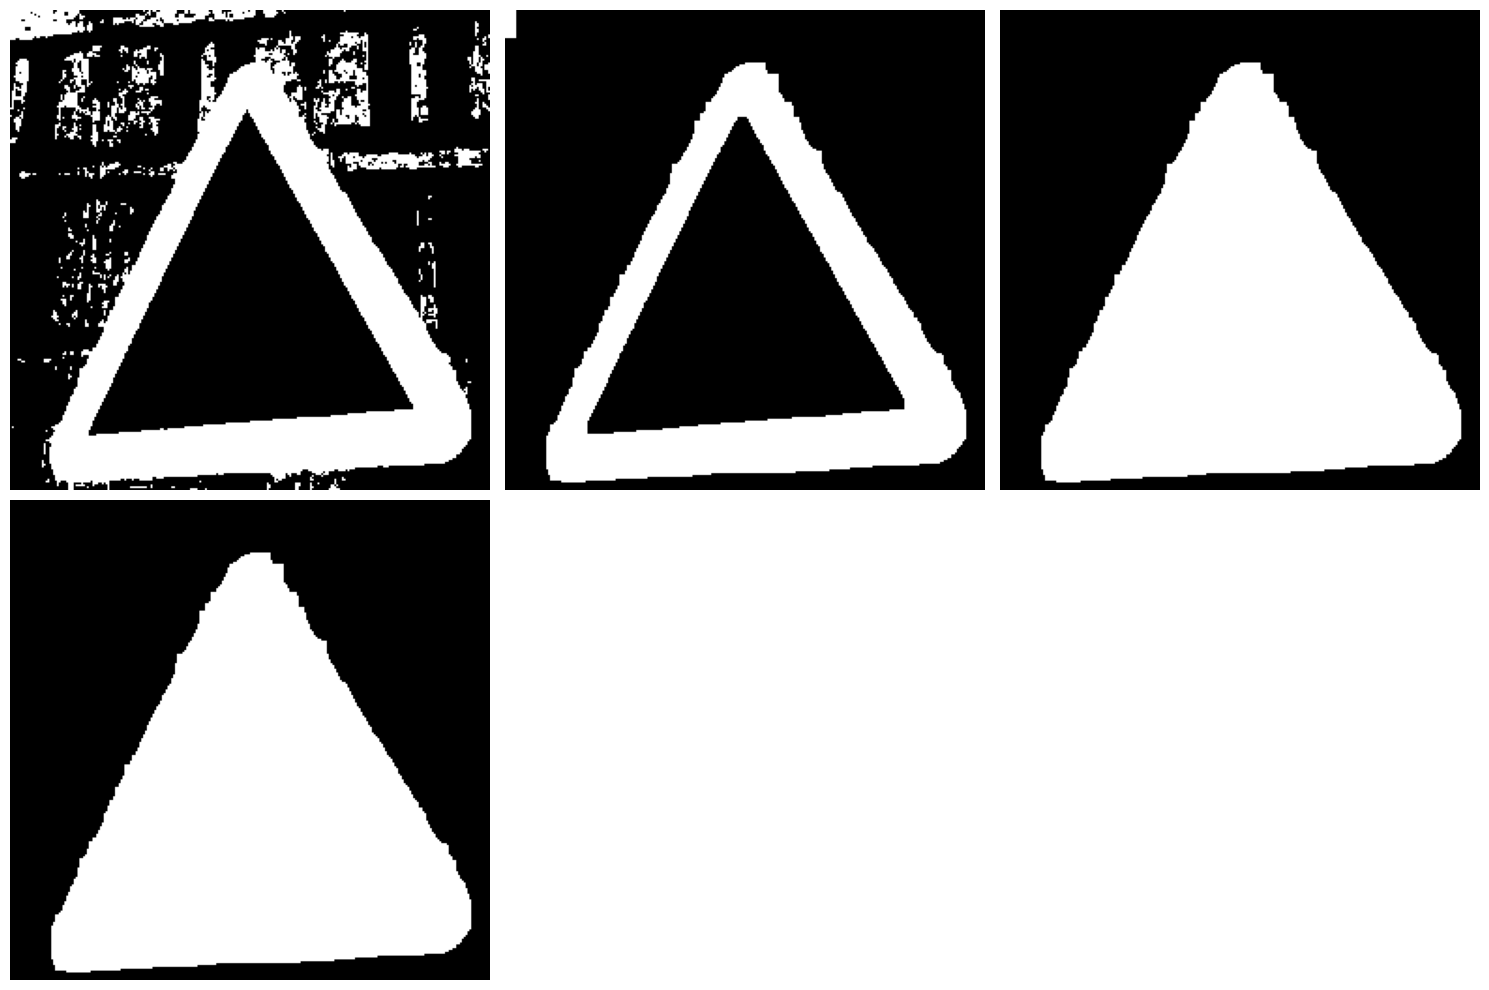

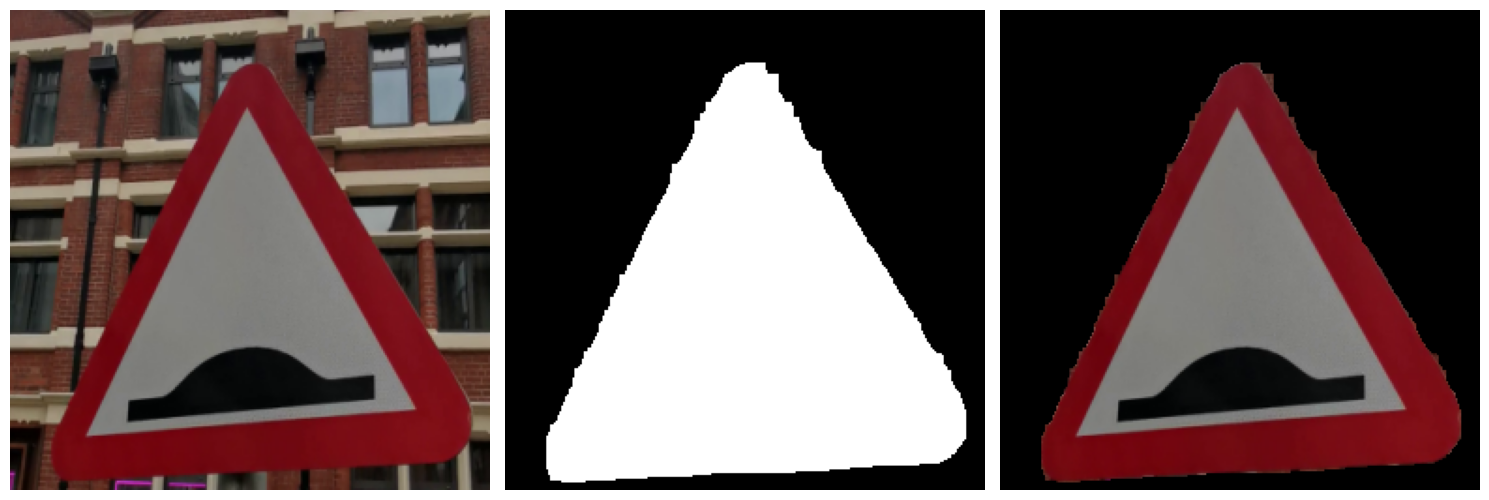

In [ ]:
def red_color_thresholding(image):
    # Convert the image to the HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define the range for detecting red color (since warning signs are usually red)
    lower_red1 = np.array([0, 50, 50])      # Lower bound for the first red range
    upper_red1 = np.array([5, 255, 255])   # Upper bound for the first red range

    lower_red2 = np.array([165, 50, 50])    # Lower bound for the second red range
    upper_red2 = np.array([180, 255, 255])  # Upper bound for the second red range

    # Mask for red regions (first and second red ranges)
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    # Combine the two masks to capture both red ranges
    mask = cv2.bitwise_or(mask1, mask2)

    return mask

# def remove_noise(mask):
#     # Apply morphological operations to remove noise
#     kernel = np.ones((5,5), np.uint8)
#     # Remove small noise
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
#     # Fill small holes
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

#     return mask
    
def contour(mask):
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create empty mask
    clean_mask = np.zeros_like(mask)
    
    # Filter contours based on area
    if contours:
        # Find the largest contour (should be the triangle)
        largest_contour = max(contours, key=cv2.contourArea)
        # Draw only the largest contour if it's above a certain area
        if cv2.contourArea(largest_contour) > 500:  # Adjust threshold as needed
            cv2.drawContours(clean_mask, [largest_contour], -1, (255), -1)
    
    return clean_mask

def remove_noise(mask):
    # Create a small kernel for erosion/dilation
    kernel = np.ones((7,7), np.uint8)
    
    # Apply erosion to smooth out the protrusions, remove noise
    eroded = cv2.erode(mask, kernel, iterations=1)
    
    # Apply dilation to restore the size
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    
    return dilated


def smooth_edges(mask):
    # Define a kernel for the morphological operations
    kernel = np.ones((11, 11), np.uint8)  # You can adjust the size of the kernel
    
    # Apply opening (erosion followed by dilation) to remove small noise
    cleaned_image = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    kernel = np.ones((5, 5), np.uint8)  # You can adjust the size of the kernel

    # Optionally, apply closing (dilation followed by erosion) to fill small holes
    cleaned_image = cv2.morphologyEx(cleaned_image, cv2.MORPH_CLOSE, kernel)
    
    return cleaned_image


def is_triangle(contour, tolerance=0.04):
    """Check if a contour is a triangle using polygon approximation."""
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, tolerance * perimeter, True)
    return len(approx) == 3, approx  # Return whether it's a triangle and the approximation


def fill_mask(mask):
    largest_contour = get_largest_contour(mask)
    new_mask = np.zeros_like(mask)
    cv2.drawContours(new_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
    return new_mask


def create_triangle_encompassing_mask(mask):
    largest_contour = get_largest_contour(mask)

    # Create a blank mask of the same size as the input mask
    triangle_mask = np.zeros_like(mask)

    # Fit a triangle around the contour
    triangle_pts = cv2.minEnclosingTriangle(largest_contour)[1]

    # Draw the triangle on the image
    triangle_pts = np.int32(triangle_pts)   

    # Ensure the points are in the right shape (Nx1x2) for drawContours
    triangle_pts = triangle_pts.reshape((-1, 1, 2))

    # Draw the triangle on the image
    cv2.drawContours(triangle_mask, [triangle_pts], -1, (255), thickness=cv2.FILLED)

    return triangle_mask

def edge_detection(image):
     # Apply edge detection (Canny) on the red masked image
    edges = cv2.Canny(image, threshold1=100, threshold2=200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask for the road sign
    sign_mask = np.zeros_like(mask)

    # Draw the contours on the mask to isolate the road sign area
    cv2.drawContours(sign_mask, contours, -1, (255), thickness=cv2.FILLED)
    
    return sign_mask

def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Assuming you're working with the largest contour (you can adjust as needed)
    largest_contour = max(contours, key=cv2.contourArea)

    return largest_contour


def is_within_10_percent(old_value, new_value):
    lower_bound = old_value * 0.9
    upper_bound = old_value * 1.1

    return lower_bound <= new_value and new_value <= upper_bound


def check_contour_area_diff(old, new):
   return is_within_10_percent(cv2.contourArea(get_largest_contour(old)), cv2.contourArea(get_largest_contour(new)))


def segment_warning_road_sign(image):
    thresholded_mask = red_color_thresholding(image)
    denoised_mask = smooth_edges(thresholded_mask)

    no_disconnect = check_contour_area_diff(thresholded_mask, denoised_mask)

    # Fallback to thresholded mask if smoothing causes contour to disconnect
    mask = denoised_mask if no_disconnect else thresholded_mask

    filled_mask = fill_mask(mask)

    no_fill = is_within_10_percent(np.sum(mask == 255), np.sum(filled_mask == 255))

    # Fallback to crude triangle drawing if contour could not be filled.
    mask = create_triangle_encompassing_mask(mask) if no_fill else filled_mask

    plot_images([thresholded_mask, denoised_mask, filled_mask, mask])

    # Segment the foreground image using the sign mask (keeping only the sign)
    segmented_foreground = cv2.bitwise_and(image, image, mask=mask)

    return mask, segmented_foreground

# Example usage
image = cv2.imread("./Task-4/road_humps_1.png")  # Path to your image file
mask, segmented_foreground = segment_warning_road_sign(image)
plot_images([image, mask, segmented_foreground], "BGR2RGB")
